In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

import os
print(os.listdir("../input"))

['train_identity.csv', 'train_transaction.csv', 'test_transaction.csv', 'test_identity.csv', 'sample_submission.csv']


In [2]:
# setting up default plotting parameters
%matplotlib inline

plt.rcParams['figure.figsize'] = [20.0, 7.0]
plt.rcParams.update({'font.size': 22,})

sns.set_palette('viridis')
sns.set_style('white')
sns.set_context('talk', font_scale=0.8)

In [3]:
#raw_identity = pd.read_csv('../input/train_identity.csv')
raw_transaction = pd.read_csv('../input/train_transaction.csv')

test = pd.read_csv('../input/test_transaction.csv')

#print('train_identity shape: ')
#print(raw_identity.shape)
print('train_transaction shape: ')
print(raw_transaction.shape)

train_transaction shape: 
(590540, 394)


In [4]:
#raw_identity.head()

In [5]:
raw_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


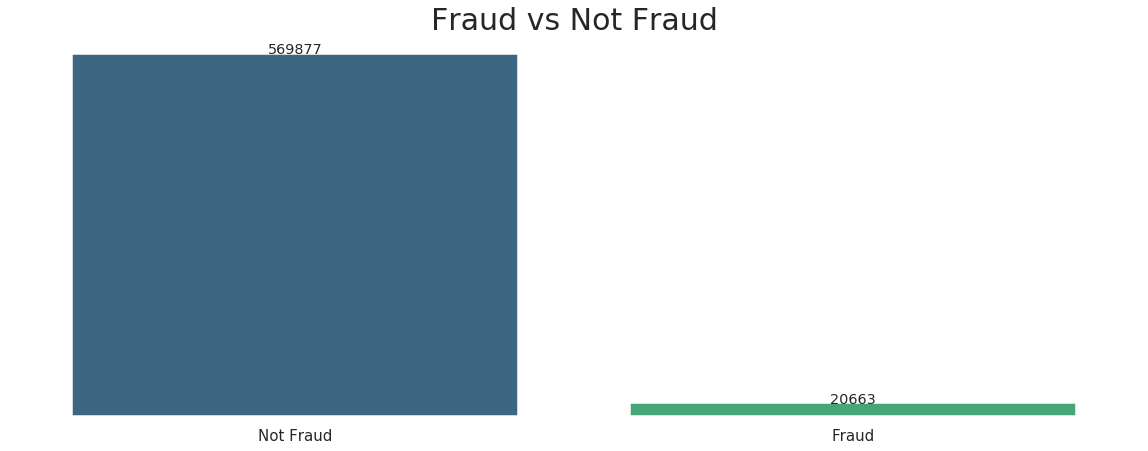

In [6]:
# using seaborns countplot to show distribution of questions in dataset
fig, ax = plt.subplots()
g = sns.countplot(raw_transaction.isFraud, palette='viridis')
g.set_xticklabels(['Not Fraud', 'Fraud'])
g.set_yticklabels([])

# function to show values on bars
def show_values_on_bars(axs):
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() + p.get_width() / 2
            _y = p.get_y() + p.get_height()
            value = '{:.0f}'.format(p.get_height())
            ax.text(_x, _y, value, ha="center") 

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
show_values_on_bars(ax)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Fraud vs Not Fraud', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

In [7]:
# print percentage of transactions where target == 1
(len(raw_transaction.loc[raw_transaction.isFraud==1])) / (len(raw_transaction.loc[raw_transaction.isFraud == 0])) * 100

3.625870143908247

In [8]:
#checking for missing values

# from https://github.com/WillKoehrsen/machine-learning-project-walkthrough/blob/master/Machine%20Learning%20Project%20Part%201.ipynb# from  
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [9]:
missing_values_table(raw_transaction).head(10)

Your selected dataframe has 394 columns.
There are 374 columns that have missing values.


,Missing Values,% of Total Values
dist2,552913,93.6
D7,551623,93.4
D13,528588,89.5
D14,528353,89.5
D12,525823,89.0
D6,517353,87.6
D9,515614,87.3
D8,515614,87.3
V157,508595,86.1
V163,508595,86.1


In [10]:
#missing_values_table(raw_identity).head(10)

In [11]:
def drop_missing_values(df, percent_drop):
    """
    Drop columns with missing values.
    
    Args:
        df = dataframe
        percent_drop = percentage of null values above which the column will be dropped
            as decimal between 0 and 1
    Returns:
        df = df where columns above percent_drop are dropped.
    
    """
    to_drop = [column for column in df if (df[column].isnull().sum()/len(df) >= percent_drop)]

    print('Columns to drop: ' , (len(to_drop)))
    # Drop features 
    df = df.drop(columns=to_drop)
    print('Shape: ', df.shape)
    return df

In [12]:
transaction = drop_missing_values(raw_transaction, 0.01)
lst = transaction.columns.values
test = test[test.columns.intersection(lst)]

transaction.shape
test.shape

Columns to drop:  283
Shape:  (590540, 111)


(506691, 110)

In [13]:
# info method to get quick description of the data
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 111 entries, TransactionID to V321
dtypes: float64(104), int64(4), object(3)
memory usage: 500.1+ MB


In [14]:
# summary of numerical attributes
transaction.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card3,card5,C1,C2,C3,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,588975.000000,586281.000000,590540.000000,590540.000000,590540.000000,...,590528.000000,589271.000000,589271.000000,589271.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,153.194925,199.278897,14.092458,15.269734,0.005644,...,39.173910,21.351473,43.319174,26.806977,109.818544,247.606741,162.153398,18.372476,42.073133,28.326584
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,11.336444,41.244453,133.569018,154.668899,0.150536,...,172.128339,95.902970,173.619028,116.853222,2270.033202,3980.042828,2793.343636,332.304848,473.499307,382.053171
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,150.000000,166.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,150.000000,226.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,150.000000,226.000000,3.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,231.000000,237.000000,4685.000000,5691.000000,26.000000,...,55125.000000,4817.470215,7519.870117,4817.470215,93736.000000,134021.000000,98476.000000,104060.000000,104060.000000,104060.000000


In [15]:
# checking missing values again
missing_values_table(transaction).head(10)

Your selected dataframe has 111 columns.
There are 91 columns that have missing values.


,Missing Values,% of Total Values
card5,4259,0.7
card4,1577,0.3
card6,1571,0.3
card3,1565,0.3
V296,1269,0.2
V282,1269,0.2
V283,1269,0.2
V288,1269,0.2
V289,1269,0.2
V281,1269,0.2


In [16]:
# find correlations to target = isFraud
corr_matrix = transaction.corr().abs()

print(corr_matrix['isFraud'].sort_values(ascending=False).head(20))

isFraud    1.000000
card3      0.154151
V123       0.138222
V302       0.132903
V304       0.131498
V303       0.124287
V111       0.121610
V113       0.115976
V283       0.112731
V125       0.111999
V112       0.105212
V282       0.104123
V108       0.096794
V114       0.096086
V110       0.081630
V116       0.080644
V124       0.076721
V281       0.072627
D1         0.067193
V109       0.060994
Name: isFraud, dtype: float64


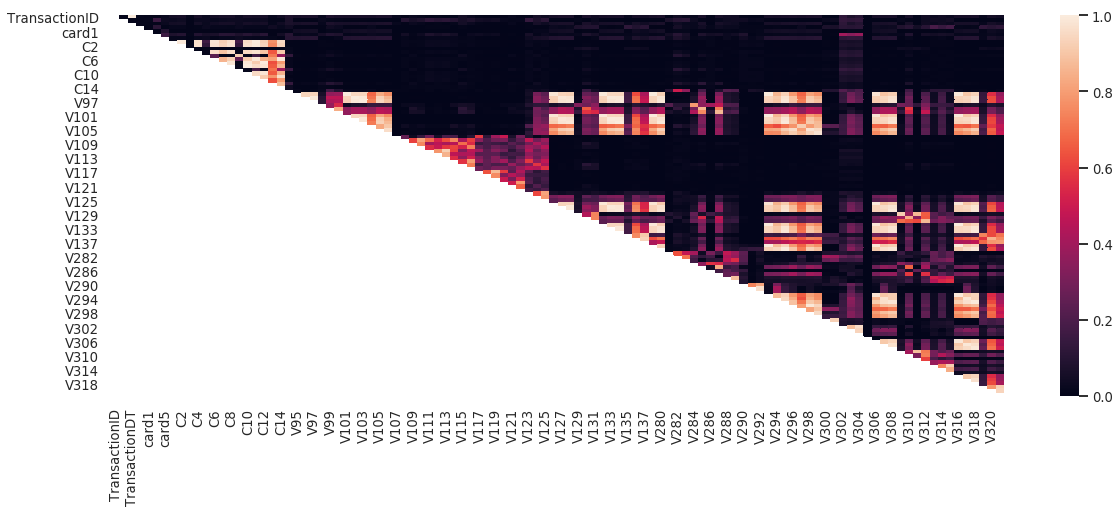

In [17]:
# Visualizing the correlation matrix
# Select upper triangle of correlation matrix

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
sns.heatmap(upper)
plt.show();

In [18]:
#checking data types of columns
transaction.dtypes

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
V317              float64
V318              float64
V319              float64
V320              float64
V321              float64
Length: 111, dtype: object

In [19]:
# checking for categorical variables
transaction.select_dtypes('object').apply(pd.Series.nunique, axis=0)

ProductCD    5
card4        4
card6        4
dtype: int64

In [20]:
y = transaction.isFraud
X = transaction.drop('isFraud', axis=1)

In [21]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

In [22]:
categorical = X[['ProductCD', 'card4', 'card6']]
X = X.drop(['ProductCD', 'card4', 'card6'], axis=1)

In [23]:
imputer.fit(X)

SimpleImputer(add_indicator=False, copy=True, fill_value=None,
              missing_values=nan, strategy='median', verbose=0)

In [24]:
X = imputer.transform(X)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [27]:
y_pred = lr.predict(X_test)

In [28]:
from sklearn.model_selection import cross_val_score
cross_val_score(lr, X_train, y_train, cv=5)

array([0.08974022, 0.08627793, 0.09375628, 0.08127452, 0.08721417])

In [29]:
test = test.drop(['ProductCD', 'card4', 'card6'], axis=1)
test = imputer.transform(test)
test_ = lr.predict(test)

In [30]:
sub = pd.read_csv('../input/sample_submission.csv', index_col='TransactionID')
sub['isFraud'] = test_
sub.to_csv('submission.csv')
sub.head()

/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWarning: Passing (type, 1) or 

,isFraud
TransactionID,
3663549,-0.002445
3663550,0.010774
3663551,0.017082
3663552,0.012933
3663553,0.000975
